# Comprehensive Credit Card Fraud Detection & Financial Anomaly Analysis

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/MSD-99/Credit_Card_Fraud_Detection_EDA_ML/blob/main/Credit_Card_Fraud_Analysis.ipynb)
![Python](https://img.shields.io/badge/Python-3.10%2B-blue?style=flat&logo=python&logoColor=white)
![Dataset](https://img.shields.io/badge/Dataset-1M%20Transactions-orange?style=flat)
![Domain](https://img.shields.io/badge/Domain-FinTech%20%26%20Fraud%20Analytics-green?style=flat)
![License](https://img.shields.io/badge/License-MIT-purple?style=flat)

---
**Dataset Source:** [Kaggle Credit Card Fraud Dataset (1,000,000 Transactions)](https://www.kaggle.com/datasets/dhanushnarayananr/credit-card-fraud)


## 📌 Project Overview
This research notebook performs an in-depth exploratory data analysis (EDA), behavioral profiling, and statistical risk evaluation on **1,000,000 credit card transactions**.

### Key Focus Areas:
1. **Severe Class Imbalance Profiling:** Assessing skewness across 8.74% fraudulent vs. 91.26% legitimate transactions.
2. **Feature Interdependence:** Pearson and Spearman correlation analysis across physical and digital attributes.
3. **Security Protocol Efficacy:** Evaluating the protective impact of PIN authentication and EMV chip verification.
4. **Behavioral Outliers:** Modeling the strong correlation between median purchase price deviations and fraud probability.
5. **Digital Vulnerabilities:** Comparing risk exposures between online and physical point-of-sale transactions.


## 1 — Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sklearn as sk

# plotting defaults
%matplotlib inline
sns.set(style='whitegrid')

## 2 — Data loading

In [3]:
DATASET_PATH = Path("./data/card_transdata.csv")
df = pd.read_csv(DATASET_PATH)
print('First 5 rows:')
df.head()

First 5 rows:


,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud
0,57.877857,0.311140,1.945940,1.0,1.0,0.0,0.0,0.0
1,10.829943,0.175592,1.294219,1.0,0.0,0.0,0.0,0.0
2,5.091079,0.805153,0.427715,1.0,0.0,0.0,1.0,0.0
3,2.247564,5.600044,0.362663,1.0,1.0,0.0,1.0,0.0
4,44.190936,0.566486,2.222767,1.0,1.0,0.0,1.0,0.0


## 3 — EDA (Exploratory Data Analysis)

In [26]:
print('Shape:', df.shape)
print('Dtypes:\n', df.dtypes.value_counts())
print('\nMissing values per column:\n', df.isna().sum().sort_values(ascending=False).head(10))
print('\nFraud counts(Normalized):\n', df['fraud'].value_counts(normalize=True))

Shape: (1000000, 8)
Dtypes:
 float64    8
Name: count, dtype: int64

Missing values per column:
 distance_from_home                0
distance_from_last_transaction    0
ratio_to_median_purchase_price    0
repeat_retailer                   0
used_chip                         0
used_pin_number                   0
online_order                      0
fraud                             0
dtype: int64

Fraud counts(Normalized):
 fraud
0.0    0.912597
1.0    0.087403
Name: proportion, dtype: float64


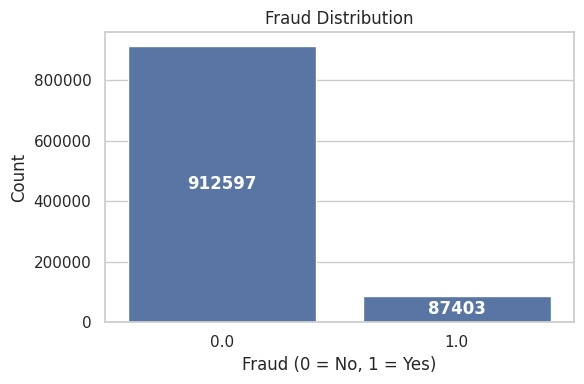

In [12]:
# Plot Fraud Distribution
plt.figure(figsize=(6,4))
ax = sns.countplot(x='fraud', data=df)
plt.title('Fraud Distribution')
plt.xlabel('Fraud (0 = No, 1 = Yes)')
plt.ylabel('Count')

# Annotate counts centered inside each bar with contrasting color
for p in ax.patches:
    height = p.get_height()
    x = p.get_x() + p.get_width() / 2
    # get bar face color and compute luminance to choose contrasting text color
    r, g, b, _ = p.get_facecolor()
    luminance = 0.299 * r + 0.587 * g + 0.114 * b
    text_color = 'white' if luminance < 0.5 else 'black'
    ax.annotate(f'{int(height)}', xy=(x, height/2), xytext=(0, 0), textcoords='offset points',
                ha='center', va='center', color=text_color, fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

## 4 — Preprocessing


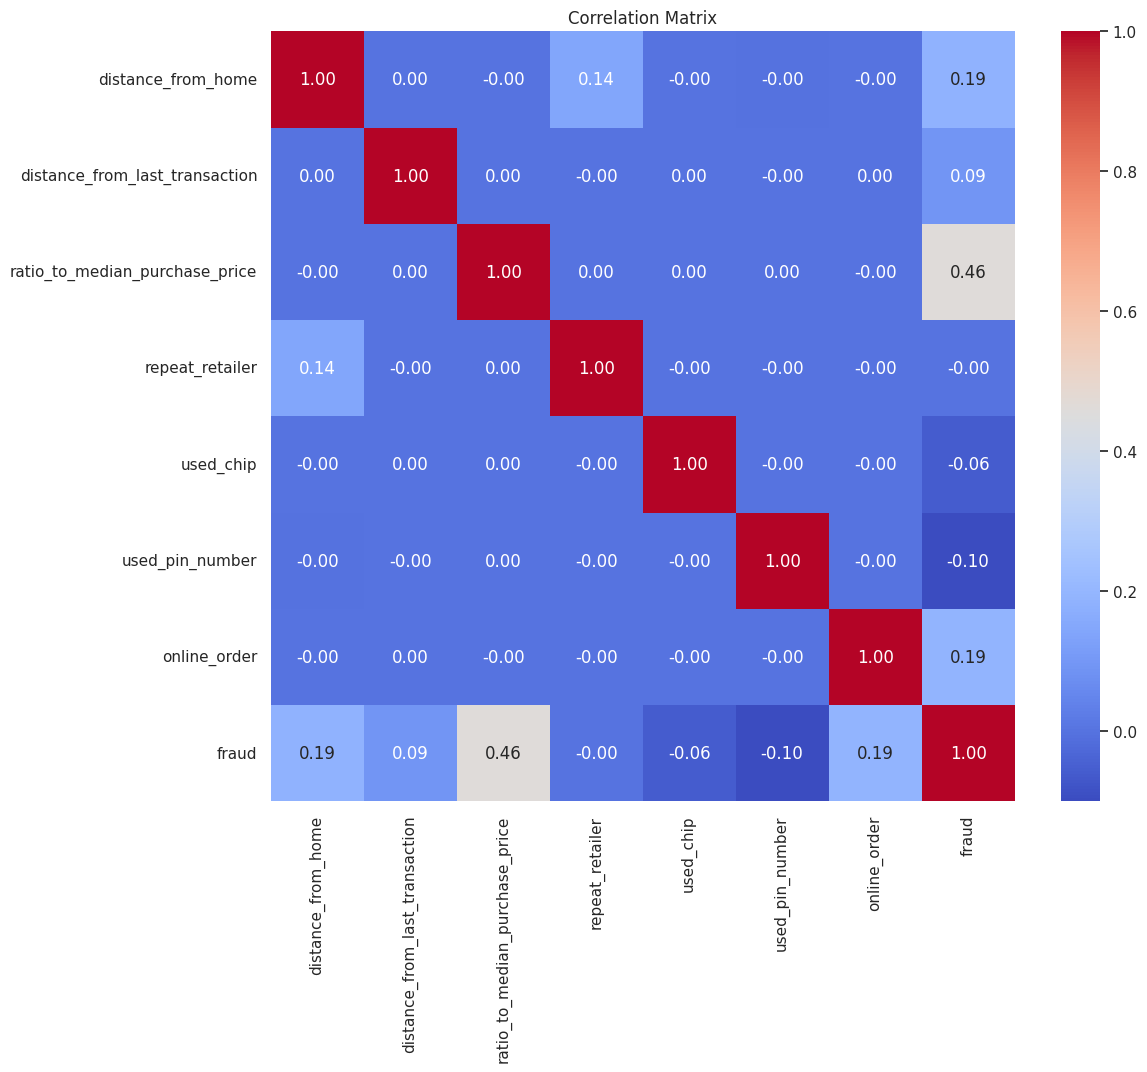

In [13]:
# Correlation Matrix
plt.figure(figsize=(12,10))
corr = df.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

## 6.a — Handling Missing Values

In [14]:
# Diagnose and handle missing values with type-aware strategies
missing_summary = (
    df.isna().sum().to_frame(name='missing_count')
    .assign(missing_pct=lambda frame: frame['missing_count'] / len(df) * 100)
    .sort_values('missing_count', ascending=False)
 )
print('Missing values per column:')
print(missing_summary)

# Apply median (numeric) or mode (categorical) imputations only where needed
numeric_cols = df.select_dtypes(include=['number']).columns
categorical_cols = df.select_dtypes(exclude=['number']).columns

imputed_df = df.copy()
for col in numeric_cols:
    if imputed_df[col].isna().any():
        imputed_df[col].fillna(imputed_df[col].median(), inplace=True)

for col in categorical_cols:
    if imputed_df[col].isna().any():
        imputed_df[col].fillna(imputed_df[col].mode(dropna=True).iloc[0], inplace=True)

if missing_summary['missing_count'].sum() == 0:
    print('\nNo missing values detected; the dataset remains unchanged.')
else:
    remaining_na = imputed_df.isna().sum().sum()
    print(f'\nRemaining missing values after imputation: {remaining_na}')

df = imputed_df

Missing values per column:
                                missing_count  missing_pct
distance_from_home                          0          0.0
distance_from_last_transaction              0          0.0
ratio_to_median_purchase_price              0          0.0
repeat_retailer                             0          0.0
used_chip                                   0          0.0
used_pin_number                             0          0.0
online_order                                0          0.0
fraud                                       0          0.0

No missing values detected; the dataset remains unchanged.


## 6.b — Security Features Analysis


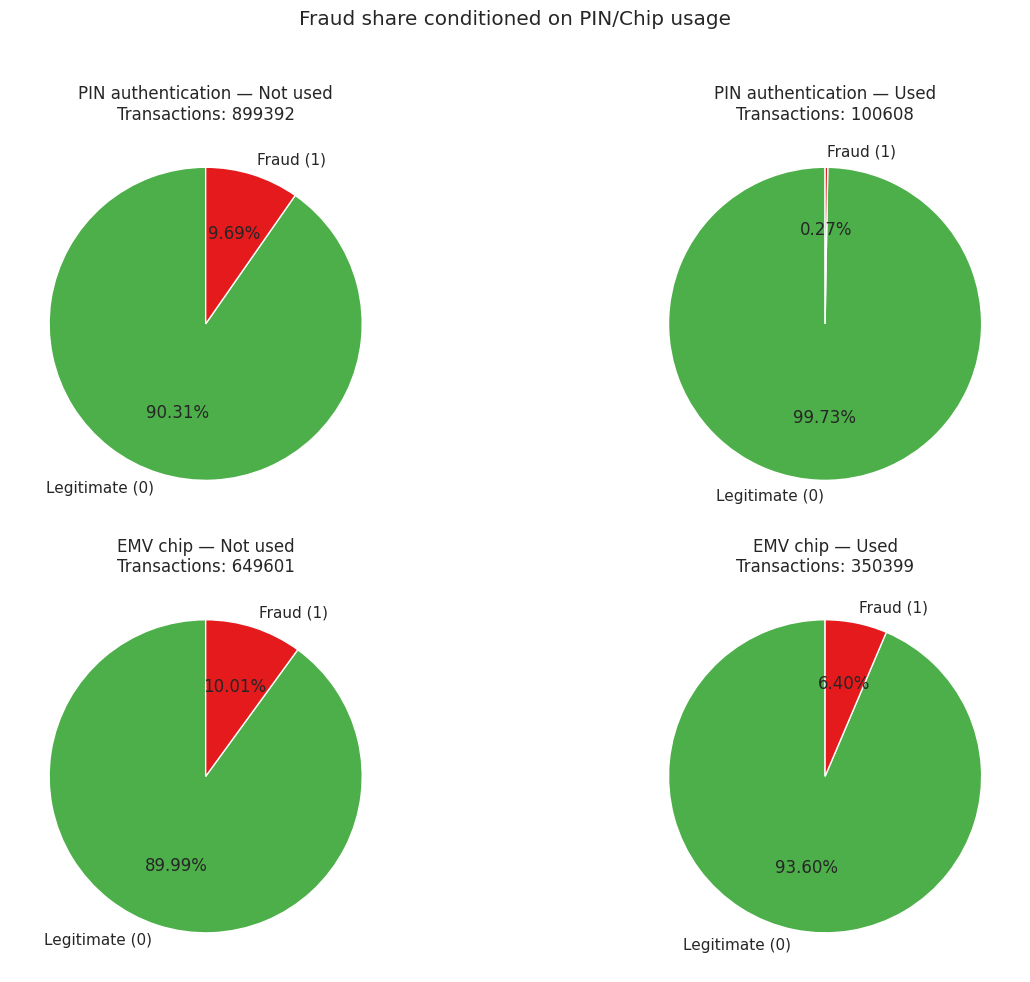

Fraud rate (%) conditional on security usage:
  used_pin_number: {0.0: 9.688, 1.0: 0.271}
  used_chip: {0.0: 10.005, 1.0: 6.396}


In [16]:
# Visualize fraud share for PIN and chip usage via pie charts
security_features = {
    'used_pin_number': 'PIN authentication',
    'used_chip': 'EMV chip'
}

fig, axes = plt.subplots(len(security_features), 2, figsize=(14, 10))
axes = axes.reshape(len(security_features), 2)

fraud_rates = {}
for row, (feature, label) in enumerate(security_features.items()):
    fraud_rates[feature] = df.groupby(feature)['fraud'].mean()
    for col, usage_flag in enumerate([0, 1]):
        subset = df[df[feature] == usage_flag]
        ax = axes[row, col]
        if subset.empty:
            ax.axis('off')
            ax.set_title(f'No records for {label} = {usage_flag}')
            continue

        counts = subset['fraud'].value_counts().reindex([0.0, 1.0], fill_value=0)
        labels = ['Legitimate (0)', 'Fraud (1)']
        colors = ['#4daf4a', '#e41a1c']
        ax.pie(counts, labels=labels, autopct='%1.2f%%', startangle=90, colors=colors)
        usage_text = 'Used' if usage_flag == 1 else 'Not used'
        ax.set_title(f'{label} — {usage_text}\nTransactions: {int(counts.sum())}')

plt.suptitle('Fraud share conditioned on PIN/Chip usage')
plt.tight_layout(rect=(0, 0, 1, 0.96))
plt.show()

print('Fraud rate (%) conditional on security usage:')
for feature, rates in fraud_rates.items():
    formatted = (rates * 100).round(3).to_dict()
    print(f"  {feature}: {formatted}")

## 6.c — Repeat Retailer Sequences


In [17]:
# Extract sequences of repeat_retailer values leading into fraud events
max_sequences = 10
repeat_series = df['repeat_retailer'].astype(int)
fraud_series = df['fraud'].astype(int)

sequences = []
current_sequence = []
for repeat_value, fraud_flag in zip(repeat_series, fraud_series):
    current_sequence.append(str(repeat_value))
    if fraud_flag == 1:
        sequences.append(' -> '.join(current_sequence))
        current_sequence = []

print(f'First {max_sequences} sequences ending with a fraud:')
for idx, seq in enumerate(sequences[:max_sequences], start=1):
    print(f"{idx:02d}. {seq}")

sequence_lengths = pd.Series([len(seq.split(' -> ')) for seq in sequences])
final_states = pd.Series([seq.split(' -> ')[-1] for seq in sequences])

print('\nSequence length summary (steps before fraud row included):')
print(sequence_lengths.describe(percentiles=[0.5, 0.9, 0.95]).round(2))

print('\nFinal repeat_retailer state frequency just before fraud:')
print(final_states.value_counts(normalize=True).sort_index().rename('frequency'))

First 10 sequences ending with a fraud:
01. 1 -> 1 -> 1 -> 1 -> 1 -> 1 -> 1 -> 1 -> 0 -> 1 -> 1 -> 1 -> 1 -> 1
02. 1 -> 1 -> 1 -> 1 -> 1 -> 1 -> 1 -> 1 -> 0 -> 1 -> 1
03. 1 -> 1 -> 1 -> 1 -> 1
04. 1 -> 1 -> 1 -> 1 -> 1 -> 1
05. 1
06. 1 -> 1 -> 1 -> 1 -> 0 -> 1 -> 1 -> 1 -> 1 -> 1 -> 1
07. 1
08. 1 -> 1 -> 1 -> 1 -> 1 -> 1
09. 1 -> 1 -> 1 -> 1 -> 1 -> 0 -> 1 -> 0 -> 1 -> 1 -> 1 -> 1 -> 1 -> 1 -> 1 -> 1 -> 1 -> 1 -> 1 -> 1 -> 1 -> 1 -> 1 -> 1 -> 1 -> 1 -> 1 -> 1 -> 1 -> 1 -> 1 -> 1 -> 1 -> 1 -> 1 -> 0 -> 1 -> 1 -> 1 -> 1 -> 1 -> 1 -> 0 -> 1 -> 0 -> 1 -> 1
10. 0 -> 1 -> 1

Sequence length summary (steps before fraud row included):
count    87403.00
mean        11.44
std         10.88
min          1.00
50%          8.00
90%         26.00
95%         33.00
max        119.00
dtype: float64

Final repeat_retailer state frequency just before fraud:
0    0.119881
1    0.880119
Name: frequency, dtype: float64


## 6.d — Ratio to Median Purchase Price vs Fraud

Pearson correlation between ratio_to_median_purchase_price and fraud: 0.4623

Average ratio_to_median_purchase_price by fraud class:
fraud
0.0    1.4236
1.0    6.0063
Name: ratio_to_median_purchase_price, dtype: float64


/tmp/ipykernel_18385/907321128.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=group_means.index.astype(int), y=group_means.values, palette=['#4daf4a', '#e41a1c'])


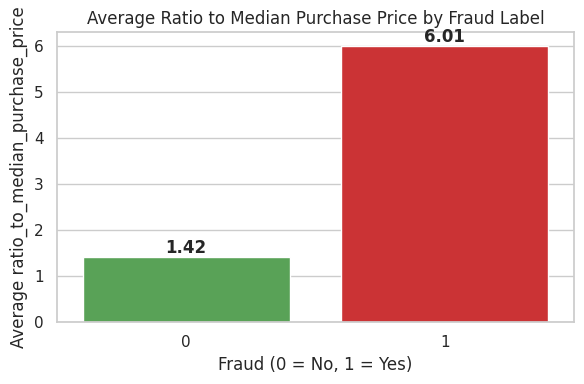

In [18]:
# Study correlation between ratio_to_median_purchase_price and fraud
ratio_col = 'ratio_to_median_purchase_price'
fraud_col = 'fraud'

pearson_corr = df[ratio_col].corr(df[fraud_col])
print(f'Pearson correlation between {ratio_col} and {fraud_col}: {pearson_corr:.4f}')

group_means = df.groupby(fraud_col)[ratio_col].mean().sort_index()
print('\nAverage ratio_to_median_purchase_price by fraud class:')
print(group_means.round(4))

plt.figure(figsize=(6, 4))
sns.barplot(x=group_means.index.astype(int), y=group_means.values, palette=['#4daf4a', '#e41a1c'])
plt.title('Average Ratio to Median Purchase Price by Fraud Label')
plt.xlabel('Fraud (0 = No, 1 = Yes)')
plt.ylabel('Average ratio_to_median_purchase_price')
for index, value in enumerate(group_means.values):
    plt.text(index, value, f'{value:.2f}', ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

**Conclusion:** Fraudulent transactions tend to exhibit a higher `ratio_to_median_purchase_price` on average, and the positive correlation confirms that outlier-sized purchases are modestly associated with fraud. While the correlation is not extremely strong, it warrants additional monitoring of unusually large spending spikes.

## 6.e — Online Transaction Fraud

Online vs offline fraud summary:
              transactions  fraudulent  fraud_rate
online_order                                      
0.0                 349448      4692.0      0.0134
1.0                 650552     82711.0      0.1271


/tmp/ipykernel_18385/151197196.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=online_fraud_stats.index.astype(int), y=online_fraud_stats['fraud_rate'], palette=['#4daf4a', '#377eb8'])


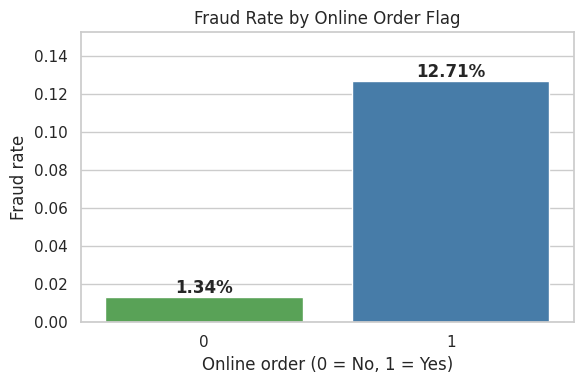

In [19]:
# Compare fraud behaviour across online and offline transactions
online_fraud_stats = (
    df.groupby('online_order')['fraud']
      .agg(['count', 'sum', 'mean'])
      .rename(columns={'count': 'transactions', 'sum': 'fraudulent', 'mean': 'fraud_rate'})
)
print('Online vs offline fraud summary:')
print(online_fraud_stats.round({'fraud_rate': 4}))

plt.figure(figsize=(6, 4))
sns.barplot(x=online_fraud_stats.index.astype(int), y=online_fraud_stats['fraud_rate'], palette=['#4daf4a', '#377eb8'])
plt.title('Fraud Rate by Online Order Flag')
plt.xlabel('Online order (0 = No, 1 = Yes)')
plt.ylabel('Fraud rate')
for idx, value in enumerate(online_fraud_stats['fraud_rate']):
    plt.text(idx, value, f'{value*100:.2f}%', ha='center', va='bottom', fontweight='bold')
plt.ylim(0, online_fraud_stats['fraud_rate'].max() * 1.2)
plt.tight_layout()
plt.show()

## 7 — NumPy Matrix Exercise

### Part 1: Base Matrix and Visualize Colored Regions

In [38]:
import matplotlib.patches as mpatches

base_matrix = np.arange(1, 31).reshape(6, 5)

print("Base matrix (6×5):")
print(base_matrix)
print()


Base matrix (6×5):
[[ 1  2  3  4  5]
 [ 6  7  8  9 10]
 [11 12 13 14 15]
 [16 17 18 19 20]
 [21 22 23 24 25]
 [26 27 28 29 30]]



In [ ]:
# Extract colored regions using slicing
# Green region extraction examples
green_slice_1 = base_matrix[0, 1:3]  
green_slice_2 = base_matrix[1:3, 2]  
green_slice_3 = base_matrix[2:4, 3]  
green_slice_4 = base_matrix[3, 4]    

print("Green region slices:")
print(f"  base_matrix[0, 1:3] = {green_slice_1}")
print(f"  base_matrix[1:3, 2] = {green_slice_2}")
print(f"  base_matrix[2:4, 3] = {green_slice_3}")
print(f"  base_matrix[3, 4] = {green_slice_4}")
print()

# Blue region extraction
blue_slice = base_matrix[2:4, 0:2] 
print("Blue region slice:")
print(f"  base_matrix[2:4, 0:2] =")
print(blue_slice)
print()

# Red region extraction examples
red_slice_1 = base_matrix[0, 3:5]    
red_slice_2 = base_matrix[4:6, 3:5]  
print("Red region slices:")
print(f"  base_matrix[0, 3:5] = {red_slice_1}")
print(f"  base_matrix[4:6, 3:5] =")
print(red_slice_2)
print()

Green region slices:
  base_matrix[0, 1:3] = [2 3]
  base_matrix[1:3, 2] = [ 8 13]
  base_matrix[2:4, 3] = [14 19]
  base_matrix[3, 4] = 20

Blue region slice:
  base_matrix[2:4, 0:2] =
[[11 12]
 [16 17]]

Red region slices:
  base_matrix[0, 3:5] = [4 5]
  base_matrix[4:6, 3:5] =
[[24 25]
 [29 30]]



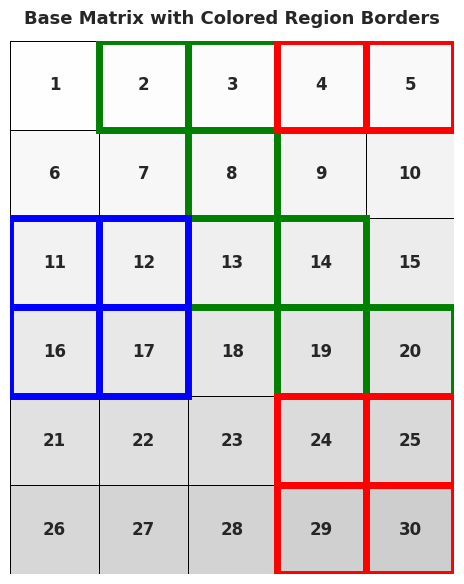

In [55]:
# Visualize
fig, ax = plt.subplots(figsize=(5, 6))

sns.heatmap(base_matrix, annot=True, fmt='d', cmap='Greys', cbar=False,
            linewidths=0.5, linecolor='black', square=True, ax=ax,
            annot_kws={'fontsize': 12, 'fontweight': 'bold'},
            vmin=0, vmax=100)

ax.set_title('Base Matrix with Colored Region Borders', fontsize=13, fontweight='bold', pad=12)


# Green borders
green_cells = [(0,1), (0,2), (1,2), (2,2), (2,3), (3,3), (3,4)]
for (i, j) in green_cells:
    rect = mpatches.Rectangle((j, i), 1, 1, 
                              linewidth=5, edgecolor='green', facecolor='none')
    ax.add_patch(rect)

# Blue borders
blue_cells = [(2,0), (2,1), (3,0), (3,1)]
for (i, j) in blue_cells:
    rect = mpatches.Rectangle((j, i), 1, 1, 
                              linewidth=5, edgecolor='blue', facecolor='none')
    ax.add_patch(rect)

# Red borders
red_cells = [(0,3), (0,4), (4,3), (4,4), (5,3), (5,4)]
for (i, j) in red_cells:
    rect = mpatches.Rectangle((j, i), 1, 1, 
                              linewidth=5, edgecolor='red', facecolor='none')
    ax.add_patch(rect)

ax.set_xticks([])
ax.set_yticks([])

plt.tight_layout()
plt.show()

### Part 2: Insert Random 4×3 Block into Matrix Center

In [52]:
# Generate a random 4×3 block with values between 10 and 70
np.random.seed(42)  # For reproducibility
random_block = np.random.randint(10, 71, size=(4, 3))

print("Random 4×3 block (values 10-70):")
print(random_block)
print()

# Create a copy of the base matrix for modification
modified_matrix = base_matrix.copy()

# Calculate center position for insertion
# Matrix is 6×5, block is 4×3
# Center row: (6-4)//2 = 1, so rows 1:5
# Center col: (5-3)//2 = 1, so cols 1:4
row_start = (modified_matrix.shape[0] - random_block.shape[0]) // 2
col_start = (modified_matrix.shape[1] - random_block.shape[1]) // 2

print(f"Inserting block at rows [{row_start}:{row_start + random_block.shape[0]}], cols [{col_start}:{col_start + random_block.shape[1]}]")
print()

# Insert the random block into the center
modified_matrix[row_start:row_start + random_block.shape[0], 
                col_start:col_start + random_block.shape[1]] = random_block

print("Modified matrix after insertion:")
print(modified_matrix)

Random 4×3 block (values 10-70):
[[48 61 38]
 [24 52 17]
 [70 30 48]
 [67 28 32]]

Inserting block at rows [1:5], cols [1:4]

Modified matrix after insertion:
[[ 1  2  3  4  5]
 [ 6 48 61 38 10]
 [11 24 52 17 15]
 [16 70 30 48 20]
 [21 67 28 32 25]
 [26 27 28 29 30]]


### Part 3: Filter and Display Values Greater Than 25

Boolean mask (True where value > 25):
[[False False False False False]
 [False  True  True  True False]
 [False False  True False False]
 [False  True  True  True False]
 [False  True  True  True False]
 [ True  True  True  True  True]]

Values greater than 25 (total: 15):
[48 61 38 52 70 30 48 67 28 32 26 27 28 29 30]



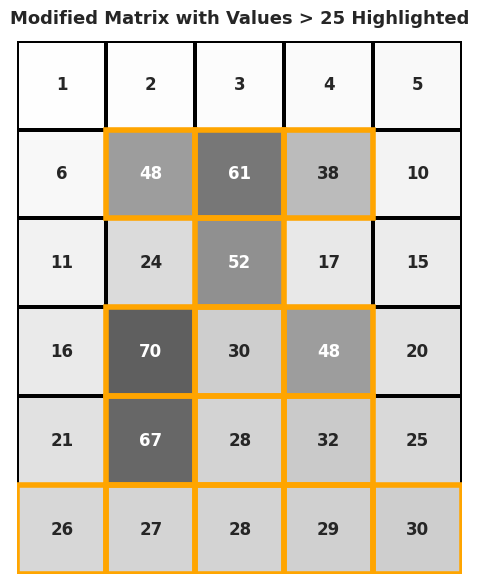

In [ ]:
# Use boolean masking to filter values > 25
boolean_mask = modified_matrix > 25

print("Boolean mask (True where value > 25):")
print(boolean_mask)
print()

# Extract values greater than 25
filtered_values = modified_matrix[boolean_mask]

print(f"Values greater than 25 (total: {len(filtered_values)}):")
print(filtered_values)
print()

# Get positions (indices) of values > 25
positions = np.argwhere(boolean_mask)

for idx, (row, col) in enumerate(positions, start=1):
    value = modified_matrix[row, col]


# Visualize the filtered matrix with highlighted cells
fig, ax = plt.subplots(figsize=(5, 6))

# Create a custom colormap: light gray for all cells
sns.heatmap(modified_matrix, annot=True, fmt='d', cmap='Greys', cbar=False,
            linewidths=1.5, linecolor='black', square=True, ax=ax,
            annot_kws={'fontsize': 12, 'fontweight': 'bold'},
            vmin=0, vmax=100)

ax.set_title('Modified Matrix with Values > 25 Highlighted', fontsize=13, fontweight='bold', pad=12)

# Highlight cells with values > 25 using orange borders
for (i, j) in positions:
    rect = mpatches.Rectangle((j, i), 1, 1, 
                              linewidth=4, edgecolor='orange', facecolor='none')
    ax.add_patch(rect)

ax.set_xticks([])
ax.set_yticks([])

plt.tight_layout()
plt.show()